# More on Correlation

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

### Definition: Code

Hence we can define $r$ in two Python functions as follows:


In [ ]:
def z_score(nums: np.ndarray) -> np.ndarray:
    z = (nums - np.mean(nums))/np.std(nums)
    return z

In [ ]:
def correlation(df: pd.DataFrame, x: str, y: str) -> float:
    z_x = z_score(df[x])
    z_y = z_score(df[y])
    return np.mean(z_x * z_y)

In [ ]:
df = pd.DataFrame({
    'x': [1, 2, 3, 4, 5, 6],
    'y': [1, 2, 3, 4, 4, 6],
})
df

,x,y
0,1,1
1,2,2
2,3,3
3,4,4
4,5,4
5,6,6


## Calculation breakdown

Here are the steps in the calculation. We will apply the steps to a simple table of values of $x$ and $y$.

In [ ]:
df = pd.DataFrame({
    'x': [1, 2, 3, 4, 5, 6],
    'y': [1, 2, 3, 4, 4, 6],
})
df

,x,y
0,1,1
1,2,2
2,3,3
3,4,4
4,5,4
5,6,6


Based on the scatter diagram, we expect that $r$ will be positive but not equal to 1.

(0.0, 7.0)

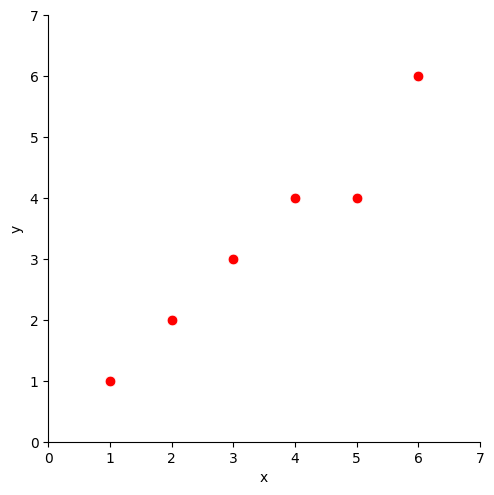

In [ ]:
g = sns.relplot(
    data=df,
    x='x', y='y',
    kind='scatter',
    s=60, color='red',
    height=5,
)
g.ax.set_xlim(0, 7)
g.ax.set_ylim(0, 7)

**Step 1.** Convert each variable to standard units.

In [ ]:
df_su = df.copy()
df_su['x_z'] = z_score(df['x'])
df_su['y_z'] = z_score(df['y'])
df_su

,x,y,x_z,y_z
0,1,1,-1.46385,-1.459601
1,2,2,-0.87831,-0.834058
2,3,3,-0.29277,-0.208514
3,4,4,0.29277,0.417029
4,5,4,0.87831,0.417029
5,6,6,1.46385,1.668115


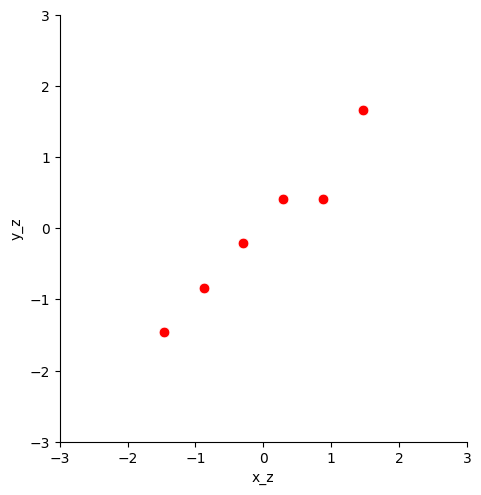

In [ ]:
g = sns.relplot(
    data=df_su,
    x='x_z', y='y_z',
    kind='scatter',
    s=60, color='red',
    height=5,
)
g.ax.set_xlim(-3, 3)
g.ax.set_ylim(-3, 3);

**Step 2.** Multiply each pair of standard units.

In [ ]:
df_su['xy_z'] = df_su['x_z'] * df_su['y_z']
t_product = df_su
t_product

,x,y,x_z,y_z,xy_z
0,1,1,-1.46385,-1.459601,2.136637
1,2,2,-0.87831,-0.834058,0.732561
2,3,3,-0.29277,-0.208514,0.061047
3,4,4,0.29277,0.417029,0.122094
4,5,4,0.87831,0.417029,0.366281
5,6,6,1.46385,1.668115,2.441871


**Step 3.** $r$ is the average of the products computed in Step 2.

In [ ]:
r = df_su['xy_z'].mean()
print(r.round(3))

0.977


As expected, **$r$ is positive** but not equal to 1.

We could've also just used our own function `correlation` like so:

In [ ]:
r = correlation(df, 'x', 'y')
print(r.round(3))

0.977


Practically, we would use one from a library such as `scipy.stats`:

In [ ]:
result = stats.pearsonr(df['x'], df['y'])

The `statistic` attribute is the correlation coefficient $r$ we're looking for.

In [ ]:
print(result.statistic.round(3))

0.977


## Correlation Measures *Linear* Association
Correlation measures only one kind of association – linear. Variables that have strong non-linear association might have very low correlation. Here is an example of variables that have a perfect quadratic relation $y = x^2$ but have correlation equal to 0.

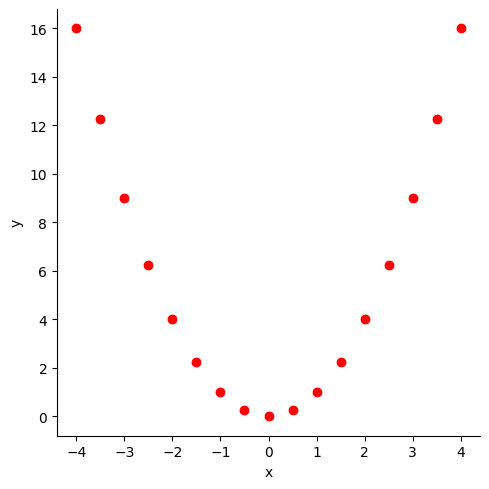

In [ ]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = pd.DataFrame({'x': new_x, 'y': new_x**2})
g = sns.relplot(
    data=nonlinear,
    x='x', y='y',
    kind='scatter',
    s=60, color='r',
    height=5,
)

In [ ]:
correlation(nonlinear, 'x', 'y')

np.float64(0.0)

## Correlation is Affected by Outliers
Outliers can have a big effect on correlation. Here is an example where a scatter plot for which $r$ is equal to 1 is turned into a plot for which $r$ is equal to 0, by the addition of just one outlying point.

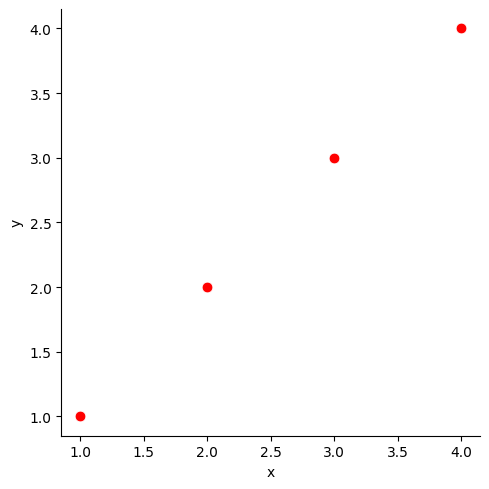

In [ ]:
line = pd.DataFrame({'x': [1, 2, 3, 4], 'y': [1, 2, 3, 4]})
g = sns.relplot(
    data=line,
    x='x', y='y',
    kind='scatter',
    height=5,
    s=60, color='r',
)

In [ ]:
correlation(line, 'x', 'y')

np.float64(1.0)

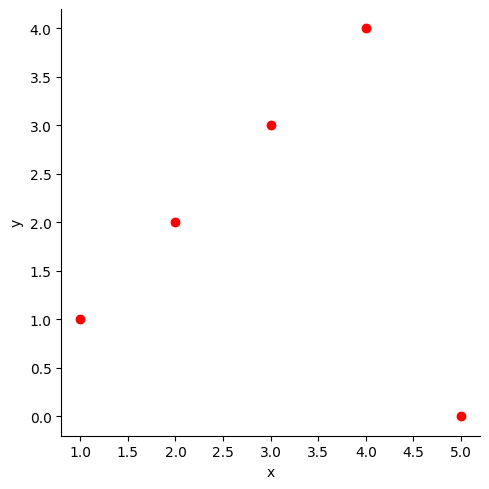

In [ ]:
outlier = pd.DataFrame({'x': [1, 2, 3, 4, 5], 'y': [1, 2, 3, 4, 0]})
g = sns.relplot(
    data=outlier,
    x='x', y='y',
    kind='scatter',
    height=5,
    s=60, color='r',
)

## Ecological Correlation

**Ecological correlation** is a correlation between two variables that are group means, in contrast to a correlation between two variables that describe individuals.

For example, one might study the correlation between physical activity and weight among sixth-grade children. A study at the individual level might make use of 100 children, then measure both physical activity and weight; the correlation between the two variables would be at the individual level.

By contrast, another study might make use of 100 classes of sixth-grade students, then measure the mean physical activity and the mean weight of each of the 100 classes. A correlation between these group means would be an example of an ecological correlation.

**Ecological fallacy**: happens when you aggregate data into groups (like classes, cities, or nations), you lose the **within-group variance**. This smoothing effect often makes correlations appear much stronger than they actually are because the "noise" of individual differences is averaged out.

### Example: Critical Reading and Math SAT scores in 2014 on 50 States

Correlations based on aggregated data can be misleading. As an example, here are data on the Critical Reading and Math SAT scores in 2014. There is one point for each of the 50 states and one for Washington, D.C. The column ``Participation Rate`` contains the percent of high school seniors who took the test. The next three columns show the average score in the state on each portion of the test, and the final column is the average of the total scores on the test.

In [ ]:
sat2014 = pd.read_csv(path_data + 'sat2014.csv').sort_values('State')
sat2014.head()

TypeError: unsupported operand type(s) for +: 'PosixPath' and 'str'

The scatter diagram of Math scores versus Critical Reading scores is very tightly clustered around a straight line; the correlation is close to 0.985. 

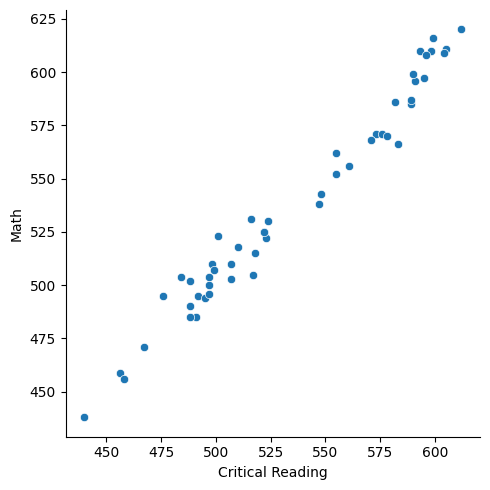

In [ ]:
g = sns.relplot(
    data=sat2014,
    x='Critical Reading', y='Math',
    kind='scatter',
    height=5,
)

In [ ]:
print(correlation(sat2014, 'Critical Reading', 'Math').round(3))

0.985


That's an extremely high correlation. But it's important to note that this does not reflect the strength of the relation between the Math and Critical Reading scores of *students*. 

The data consist of average scores in each state. **But states don't take tests – students do**. The data in the table have been created by lumping all the students in each state into a single point at the average values of the two variables in that state. But not all students in the state will be at that point, as students vary in their performance. If you plot a point for each student instead of just one for each state, there will be a cloud of points around each point in the figure above. The overall picture will be more fuzzy. **The correlation between the Math and Critical Reading scores of the students will be *lower* than the value calculated based on state averages**.

Correlations based on aggregates and averages are called *ecological correlations* and are frequently reported. As we have just seen, they must be interpreted with care.

---